<a href="https://colab.research.google.com/github/khanrakshinda23-collab/Netflix-Data-Analysis/blob/main/Netflix_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
with open("/content/netflix_titles.csv","r", encoding = "latin1") as file:
 print(file.readline())

show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description



In [ ]:
import pandas as pd

pd.read_csv(
    "/content/netflix_titles.csv",
    sep=';',
    encoding='utf-8',
    header=0,
    on_bad_lines='skip'
)




,"show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description"
0,"s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,..."
1,"s2,TV Show,Blood & Water,,""Ama Qamata, Khosi N..."
2,"s3,TV Show,Ganglands,Julien Leclercq,""Sami Bou..."
3,"s4,TV Show,Jailbirds New Orleans,,,,""September..."
4,"s5,TV Show,Kota Factory,,""Mayur More, Jitendra..."
...,...
8798,"s8803,Movie,Zodiac,David Fincher,""Mark Ruffalo..."
8799,"s8804,TV Show,Zombie Dumb,,,,""July 1, 2019"",20..."
8800,"s8805,Movie,Zombieland,Ruben Fleischer,""Jesse ..."
8801,"s8806,Movie,Zoom,Peter Hewitt,""Tim Allen, Cour..."


In [ ]:
df = pd.read_csv('/content/netflix_titles.csv')


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.sample(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5371,s5372,Movie,Aditi Mittal: Things They Wouldn't Let Me Say,Fazila Allana,Aditi Mittal,India,"July 18, 2017",2017,TV-MA,63 min,Stand-Up Comedy,Trailblazing comic Aditi Mittal mixes topical ...
4534,s4535,Movie,Super Monsters Save Halloween,NaN,"Elyse Maloway, Vincent Tong, Erin Matthews, An...",NaN,"October 5, 2018",2018,TV-Y,25 min,Children & Family Movies,The Super Monsters use their powers to get the...
4735,s4736,Movie,Tere Naal Love Ho Gaya,Mandeep Kumar,"Riteish Deshmukh, Genelia D'Souza, Tinnu Anand...",India,"August 2, 2018",2012,TV-14,127 min,"Comedies, International Movies, Romantic Movies",Mini isn't eager to wed the rich suitor who's ...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


# Data Cleaning

In [ ]:
#df["date_added"] = pd.to_datetime(df["date_added"].str.strip())

In [ ]:
mask = pd.to_datetime(df["date_added"], errors="coerce").isna()
print(df.loc[mask, "date_added"])

6066                   NaN
6079        August 4, 2017
6174                   NaN
6177     December 23, 2018
6213     December 15, 2018
               ...        
8539       January 8, 2018
8557     December 25, 2015
8684        August 1, 2017
8712        March 31, 2017
8755      November 1, 2016
Name: date_added, Length: 98, dtype: object


In [ ]:
df["date_added"] = df["date_added"].str.strip()

df["date_added"] = pd.to_datetime(
    df["date_added"],
    format="%B %d, %Y",
    errors="coerce"
).dt.date

In [ ]:
df["date_added"].isnull().sum()

np.int64(10)

In [ ]:
# df["date_added"] = pd.to_datetime(df['date_added'], errors = "coerce")

In [ ]:
before = df["date_added"].isnull().sum()
after = pd.to_datetime(df["date_added"], errors="coerce").isnull().sum()
print(before, after)

10 10


In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [ ]:
df["date_added"].dt.date

,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24
3,2021-09-24
4,2021-09-24
...,...
8802,2019-11-20
8803,2019-07-01
8804,2019-11-01
8805,2020-01-11


In [ ]:
# df['date_added'].str.strip()
df['date_added'].fillna(method='ffill', inplace=True)

/tmp/ipykernel_10507/2792074978.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date_added'].fillna(method='ffill', inplace=True)


In [ ]:
df["date_added"].isnull().sum()

np.int64(0)

In [ ]:
df["month"] = pd.to_datetime(df["date_added"]).dt.month


In [ ]:
df['month'] = df['month'].astype('Int64')


In [ ]:
df["year"] = pd.to_datetime(df["date_added"]).dt.year

In [ ]:

df["year"] = df["year"].astype('Int64')

In [ ]:
df["day"] = pd.to_datetime(df["date_added"]).dt.day_name()

In [ ]:
df["genre"] = df['listed_in'].str.strip()
df["genre"] = df["listed_in"].str.split(",").str[0]

In [ ]:
df.genre.unique()

array(['Documentaries', 'International TV Shows', 'Crime TV Shows',
       'Docuseries', 'TV Dramas', 'Children & Family Movies', 'Dramas',
       'British TV Shows', 'Comedies', 'TV Comedies', 'Thrillers',
       'Horror Movies', "Kids' TV", 'Action & Adventure', 'Reality TV',
       'Anime Series', 'International Movies', 'Sci-Fi & Fantasy',
       'Classic Movies', 'TV Shows', 'Stand-Up Comedy',
       'TV Action & Adventure', 'Movies', 'Stand-Up Comedy & Talk Shows',
       'Classic & Cult TV', 'Anime Features', 'Romantic TV Shows',
       'Cult Movies', 'Independent Movies', 'TV Horror',
       'Spanish-Language TV Shows', 'Music & Musicals', 'Romantic Movies',
       'LGBTQ Movies', 'TV Sci-Fi & Fantasy', 'Sports Movies'],
      dtype=object)

In [ ]:
df['release_year'] = pd.to_datetime(df['release_year'], format='%Y', errors='coerce')
df["release_year"] = df["release_year"].dt.year.astype("int64")

In [ ]:
df['country'] = df["country"].str.strip()
df["country"] = df["country"].str.split(',').str[0]

In [ ]:
df["director"] = df["director"].fillna("Unknown")

In [ ]:
df["cast"] = df['cast'].fillna('Not Available')

In [ ]:

df["country"] = df['country'].fillna('Not Available')

In [ ]:
df[df["rating"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month,year,day,genre
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,Unknown,"Oprah Winfrey, Ava DuVernay",Not Available,2017-01-26,2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...,1,2017,Thursday,Movies
6827,s6828,TV Show,Gargantia on the Verdurous Planet,Unknown,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,2016-12-01,2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel...",12,2016,Thursday,Anime Series
7312,s7313,TV Show,Little Lunch,Unknown,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,2018-02-01,2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take...",2,2018,Thursday,Kids' TV
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,2017-03-01,2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c...",3,2017,Wednesday,Dramas


In [ ]:
df.loc[df["show_id"]== "s5990","rating"]="TV-PG"
df.loc[df["show_id"]== "s6828","rating"]="TV-PG"
df.loc[df["show_id"]== "s7313","rating"]="Tv-PG"
df.loc[df["show_id"]== "s7538","rating"]="TV-MA"

In [ ]:
df["rating"].isnull().sum()

np.int64(0)

In [ ]:

df[df["duration"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month,year,day,genre
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi...",4,2017,Tuesday,Movies
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...,9,2016,Friday,Movies
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...,8,2016,Monday,Movies


In [ ]:
df.loc[df["show_id"]== "s5542","duration"]="74 min"
df.loc[df["show_id"]== "s5795","duration"]="84 min"
df.loc[df["show_id"]== "s5814","duration"]="66 min"


In [ ]:

df.loc[df["show_id"]== "s5542","rating"] = 'TV-MA'
df.loc[df["show_id"]== "s5795","rating"] = 'TV-MA'
df.loc[df["show_id"]== "s5814","rating"] = 'TV-MA'

In [ ]:

df["country"].value_counts()

,count
country,
United States,3211
India,1008
Not Available,831
United Kingdom,628
Canada,271
...,...
West Germany,1
Slovenia,1
Guatemala,1


In [ ]:
df.describe()

,date_added,release_year,month,year
count,8807,8807.000000,8807.0,8807.0
mean,2019-05-16 14:22:10.123765248,2014.180198,6.653685,2018.870217
min,2008-01-01 00:00:00,1925.000000,1.0,2008.0
25%,2018-04-04 00:00:00,2013.000000,4.0,2018.0
50%,2019-07-01 00:00:00,2017.000000,7.0,2019.0
75%,2020-08-18 00:00:00,2019.000000,10.0,2020.0
max,2021-09-25 00:00:00,2021.000000,12.0,2021.0
std,NaN,8.819312,3.43612,1.574361


In [ ]:
df.skew(numeric_only=True).reset_index()

,index,0
0,release_year,-3.446565
1,month,-0.060001
2,year,-0.702238


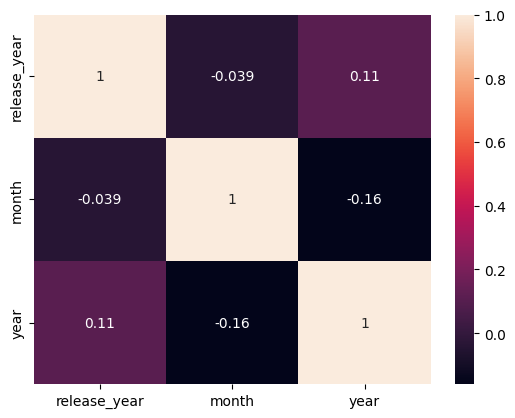

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.show()

In [ ]:
b = df.groupby("release_year")["type"].value_counts().reset_index()
b

,release_year,type,count
0,1925,TV Show,1
1,1942,Movie,2
2,1943,Movie,3
3,1944,Movie,3
4,1945,Movie,3
...,...,...,...
114,2019,TV Show,397
115,2020,Movie,517
116,2020,TV Show,436
117,2021,TV Show,315


In [ ]:
#df.drop(columns=['date_added','cast','description'],inplace = True)

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'month', 'year', 'day', 'genre'],
      dtype='object')

In [ ]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month,year,day,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",9,2021,Saturday,Documentaries
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",9,2021,Friday,International TV Shows


# Feature Engineering

In [ ]:
df[['duration_value',"duration_unit"]] = df["duration"].str.split(" ",expand = True)

In [ ]:
df["duration_value"] = df["duration_value"].astype('int64')

In [ ]:
df["duration_unit"] = df["duration_unit"].astype(str)

In [ ]:
(df.drop(columns = ["listed_in","description"])).head(1)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,month,year,day,genre,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,9,2021,Saturday,Documentaries,90,min


In [ ]:
df[["duration_unit","duration_value"]]

,duration_unit,duration_value
0,min,90
1,Seasons,2
2,Season,1
3,Season,1
4,Seasons,2
...,...,...
8802,min,158
8803,Seasons,2
8804,min,88
8805,min,88


In [ ]:
df["movie_length"] = None

df.loc[(df["type"] == "Movie") & (df["duration_value"] < 60), "movie_length"] == "Short"
df.loc[(df["type"] == "Movie") & (df["duration_value"].between(60,120)), "movie_length"] = "Medium"
df.loc[(df["type"] == "Movie") & (df["duration_value"] > 120), "movie_length"] == "Long"



,movie_length
7,False
12,False
22,False
24,False
26,False
...,...
8772,False
8773,False
8788,False
8798,False


In [ ]:
print(df['movie_length'].value_counts())

movie_length
Medium    4531
Name: count, dtype: int64


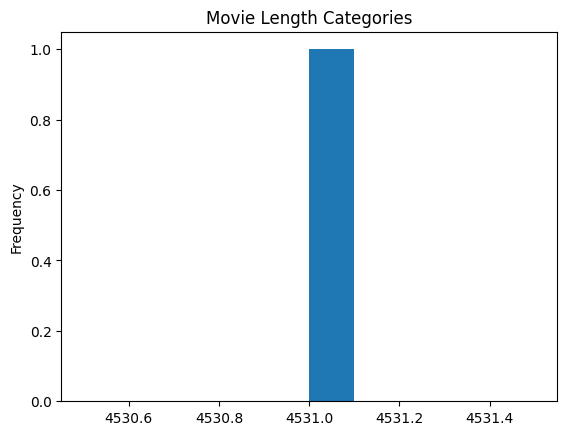

In [ ]:
import matplotlib.pyplot as plt

df['movie_length'].value_counts().plot(kind='hist')
plt.title("Movie Length Categories")
plt.show()

In [ ]:
df['show_length'] = None

df.loc[(df['type'] == 'TV Show') & (df['duration_value'] == 1), 'show_length'] = 'Mini Series'
df.loc[(df['type'] == 'TV Show') & (df['duration_value'].between(2,4)), 'show_length'] = 'Short Series'
df.loc[(df['type'] == 'TV Show') & (df['duration_value'] >= 5), 'show_length'] = 'Long Series'

In [ ]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month,year,day,genre,duration_value,duration_unit,movie_length,show_length
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",9,2021,Saturday,Documentaries,90,min,Medium,None
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",9,2021,Friday,International TV Shows,2,Seasons,None,Short Series
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Available,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,9,2021,Friday,Crime TV Shows,1,Season,None,Mini Series
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Not Available,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",9,2021,Friday,Docuseries,1,Season,None,Mini Series
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,9,2021,Friday,International TV Shows,2,Seasons,None,Short Series
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",11,2019,Wednesday,Cult Movies,158,min,None,None
8803,s8804,TV Show,Zombie Dumb,Unknown,Not Available,Not Available,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",7,2019,Monday,Kids' TV,2,Seasons,None,Short Series
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,11,2019,Friday,Comedies,88,min,Medium,None
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",1,2020,Saturday,Children & Family Movies,88,min,Medium,None


# Data Visualization

In [ ]:
#df.groupby("rating")["movies"].sort_values().head()

In [ ]:
top_genre = df["genre"].value_counts().reset_index().head(10)
top_genre

,genre,count
0,Dramas,1600
1,Comedies,1210
2,Action & Adventure,859
3,Documentaries,829
4,International TV Shows,774
5,Children & Family Movies,605
6,Crime TV Shows,399
7,Kids' TV,388
8,Stand-Up Comedy,334
9,Horror Movies,275


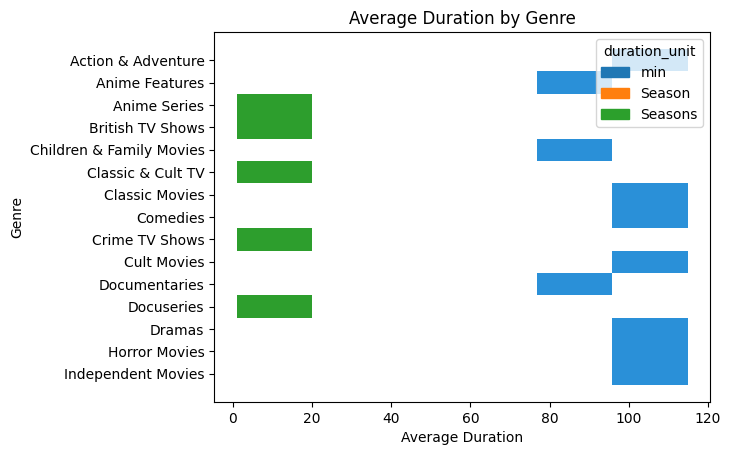

In [ ]:
h = df.groupby(["genre", "duration_unit"])["duration_value"].mean().reset_index().head(20)

sns.histplot(
    data=h,
    y="genre",
    x="duration_value",
    hue="duration_unit"
)

plt.title("Average Duration by Genre")
plt.xlabel("Average Duration")
plt.ylabel("Genre")
plt.show()

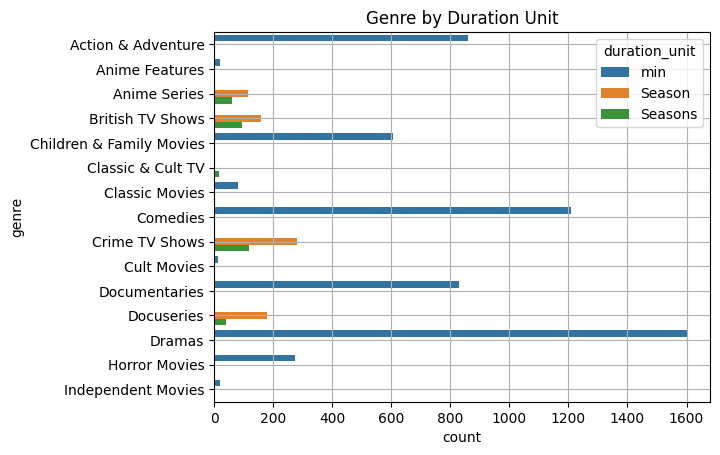

In [ ]:
h = df.groupby(["genre", "duration_unit"]).size().reset_index(name="count").head(20)

sns.barplot(
    data=h,
    y="genre",
    x="count",
    hue="duration_unit"
)

plt.title("Genre by Duration Unit")
plt.grid()
plt.show()

In [ ]:
top_genre = df["genre"].value_counts().reset_index().head(10)

fig = px.bar(
    top_genre,
    x="count",
    y="genre",
    title="Top 10 Genres Over Years"
)

fig.show()

In [ ]:
country_counts = df["country"].value_counts().head(10).reset_index()
country_counts

,country,count
0,United States,3211
1,India,1008
2,Not Available,831
3,United Kingdom,628
4,Canada,271
5,Japan,259
6,France,212
7,South Korea,211
8,Spain,181
9,Mexico,134


In [ ]:
fig = px.bar(country_counts, x = 'country' , y = "count", title = "Top 10 Countries by Netflix Content")
fig.show()

In [ ]:
# df.groupby("type")["Count"].value_counts().sort_values().head()

In [ ]:
pd.crosstab(df['country'], df['type']).sort_values(by='Movie', ascending=False).head(10).reset_index()


type,country,Movie,TV Show
0,United States,2364,847
1,India,927,81
2,Not Available,440,391
3,United Kingdom,382,246
4,Canada,187,84
5,France,148,64
6,Spain,129,52
7,Egypt,98,14
8,Nigeria,87,9
9,Mexico,86,48


<Axes: xlabel='release_year', ylabel='count'>

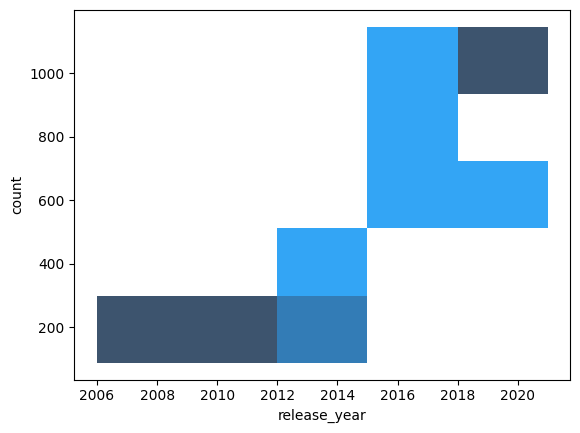

In [ ]:
r = df['release_year'].value_counts().reset_index().head(16)
r

sns.histplot(r, x = "release_year", y = "count")

In [ ]:

r.columns = ['release_year', 'count']
r = r.sort_values('release_year')
fig = px.line(r,title = "Content Release Trend", y = "count", x = "release_year",markers=True)
fig.show()

In [ ]:
import plotly.express as px

fig = px.bar(
    df,
    x="release_year",
    y="type",
    color="type",
    title="Netflix Content Growth Over Years"
)

fig.show()

In [ ]:
a = df.groupby("country")["release_year"].value_counts().reset_index()
a

,country,release_year,count
0,,2014,1
1,,2021,1
2,Argentina,2018,13
3,Argentina,2020,13
4,Argentina,2017,12
...,...,...,...
882,Vietnam,2016,1
883,Vietnam,2020,1
884,Vietnam,2021,1
885,West Germany,1977,1


* Data Visualization - Part 1:
* Create visualizations to represent the distribution of content over different genres.

* Data Visualization - Part 2:
* Visualize the distribution of content across release years.

* Data Visualization - Part 3:
* Explore the geographical distribution of content (if applicable).


In [ ]:
top_genre = df["genre"].value_counts().reset_index()

top_genre.columns = ['genre', 'count']

fig = px.bar(top_genre,
             x='count',
             y='genre',
             orientation='h',
             title="Top 10 Genres on Netflix")

fig.show()

In [ ]:
fig = px.histogram(df,
                   x='release_year',
                   nbins=30,
                   title="Distribution of Release Years")

fig.show()

In [ ]:
top10 = df.country.value_counts().reset_index().head(10)

fig = px.bar(
    top10,
    x='country',
    y='count',
    title='Top 10 Countries Producing Netflix Content',
    text='count'
)

fig.show()

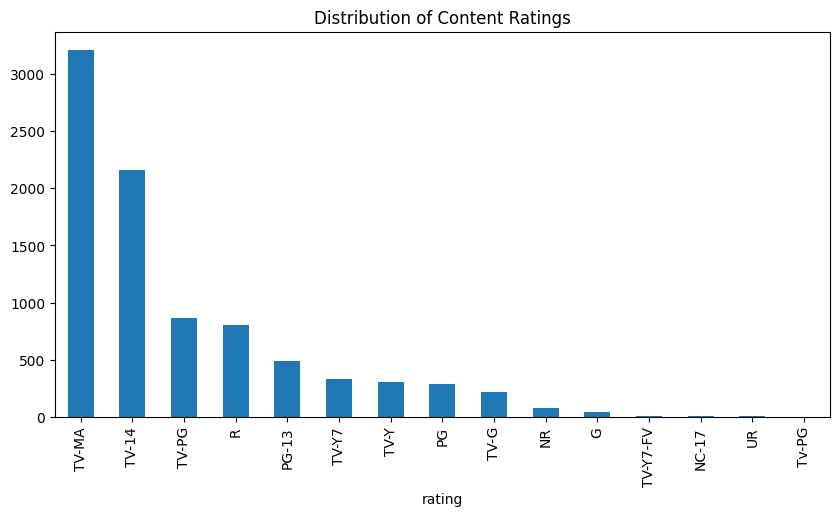

In [ ]:
df['rating'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Distribution of Content Ratings")
plt.show()

In [ ]:
movies = df[df['type']=='Movie']
movies['duration_value'].describe()

,duration_value
count,6131.000000
mean,99.564998
std,28.289504
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


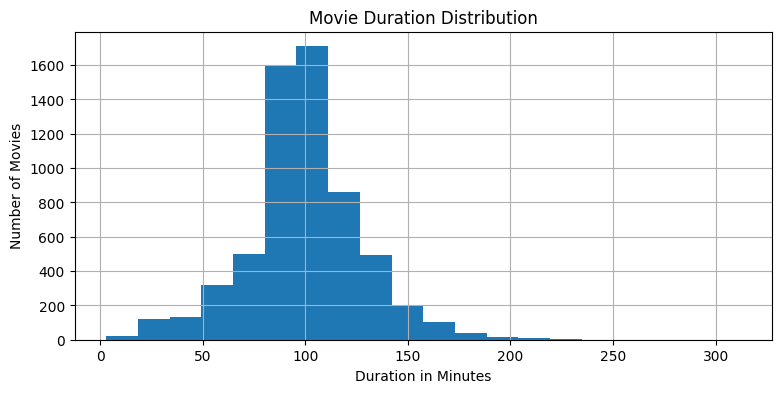

In [ ]:
plt.figure(figsize=(9,4))

movies['duration_value'].hist(bins=20)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration in Minutes")
plt.ylabel("Number of Movies")

plt.show()

In [ ]:
df[df['type']=='TV Show'].sort_values('duration_value', ascending=False)[['title','duration']].head(10).reset_index()

,index,title,duration
0,548,Grey's Anatomy,17 Seasons
1,2423,Supernatural,15 Seasons
2,4798,NCIS,15 Seasons
3,7847,Red vs. Blue,13 Seasons
4,4220,COMEDIANS of the world,13 Seasons
5,1354,Heartland,13 Seasons
6,5412,Criminal Minds,12 Seasons
7,4964,Trailer Park Boys,12 Seasons
8,6456,Cheers,11 Seasons
9,6795,Frasier,11 Seasons


In [ ]:
df.groupby("genre")["year"].size().reset_index(name='count')

,genre,count
0,Action & Adventure,859
1,Anime Features,21
2,Anime Series,176
3,British TV Shows,253
4,Children & Family Movies,605
5,Classic & Cult TV,22
6,Classic Movies,80
7,Comedies,1210
8,Crime TV Shows,399
9,Cult Movies,12


In [ ]:
movies[['release_year','duration_value']].corr()

,release_year,duration_value
release_year,1.000000,-0.206305
duration_value,-0.206305,1.000000


In [ ]:
df['genre'].nunique()

36

In [ ]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,description,month,year,day,genre,duration_value,duration_unit,movie_length,show_length,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,...,"As her father nears the end of his life, filmm...",9,2021,Saturday,Documentaries,90,min,Medium,None,2021


In [ ]:
temp = df.groupby('release_year')["genre"].value_counts().reset_index().head(10)

In [ ]:
pivot = temp.pivot(index='genre', columns='release_year', values='count').fillna(0)

import plotly.express as px
px.imshow(pivot, aspect='auto', title='Genre Release Density by Year')

In [ ]:
# Data visualization

# Data Visualization

## UNIVARIATE

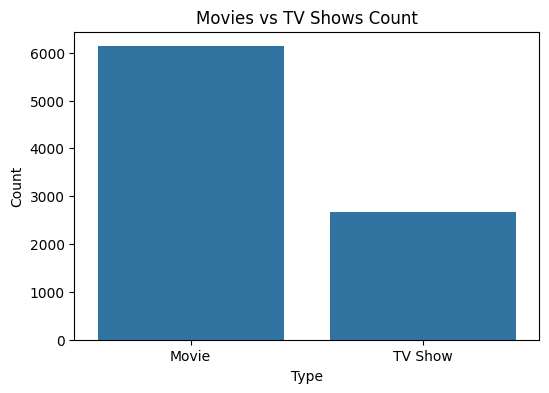

In [ ]:
type_count = df["type"].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(
    x=type_count.index,
    y=type_count.values)
plt.title("Movies vs TV Shows Count")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

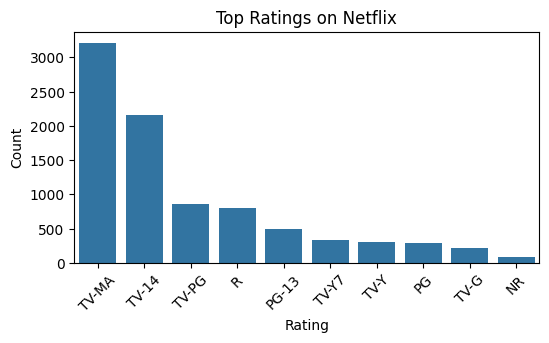

In [ ]:
rating_count = df["rating"].value_counts().head(10)
plt.figure(figsize=(6,3))
sns.barplot(x=rating_count.index, y=rating_count.values)
plt.title("Top Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

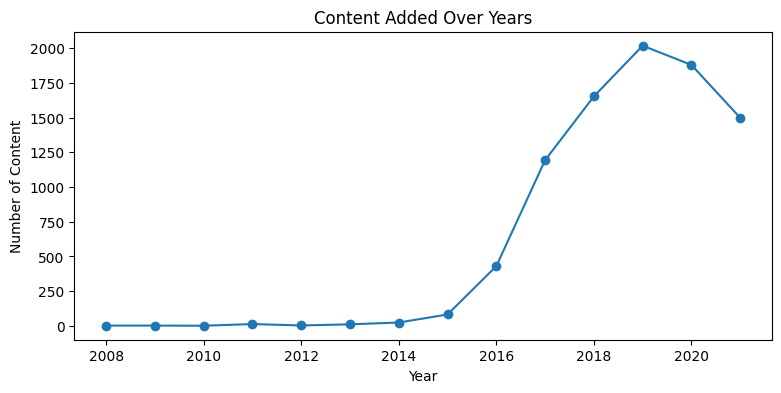

In [ ]:
df["date_added"] = pd.to_datetime(df["date_added"])
df["year_added"] = df["date_added"].dt.year
year_count = df["year_added"].value_counts().sort_index()
plt.figure(figsize=(9,4))
plt.plot( year_count.index, year_count.values, marker="o")
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Content")
plt.show()

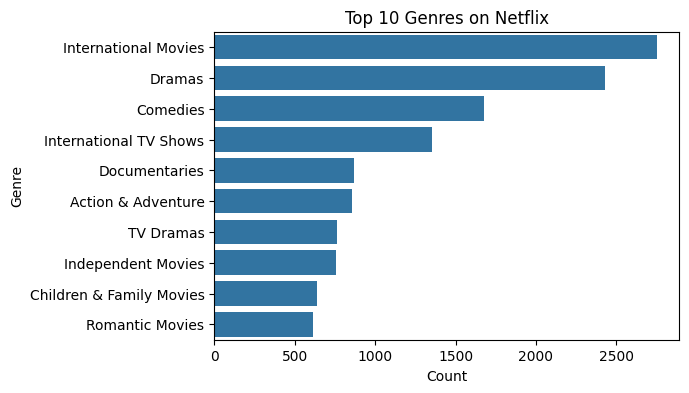

In [ ]:
genre_count = df["listed_in"].str.split(", ").explode().value_counts().head(10)

plt.figure(figsize=(6,4))
sns.barplot( x=genre_count.values, y=genre_count.index)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

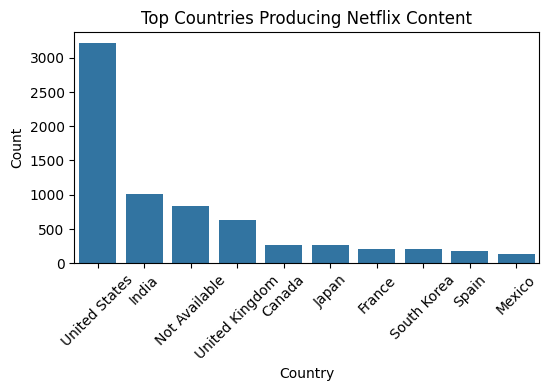

In [ ]:
country_count = df["country"].str.split(", ").explode().value_counts().head(10)

plt.figure(figsize=(6,3))
sns.barplot( x=country_count.index, y=country_count.values)
plt.title("Top Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

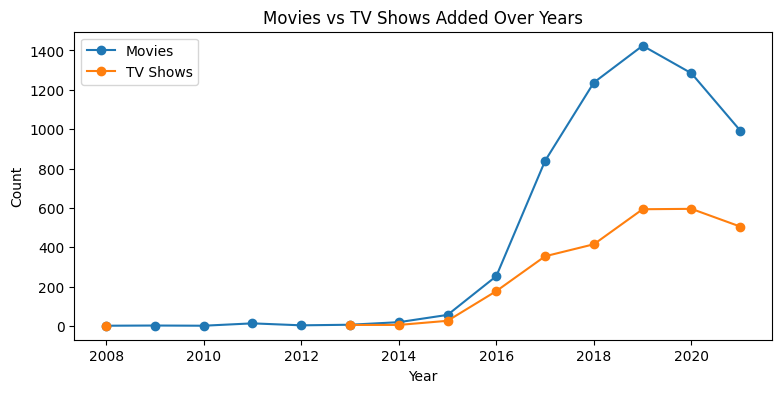

In [ ]:

content_year = df.groupby(["year_added", "type"]).size().unstack()
plt.figure(figsize=(9,4))
plt.plot( content_year.index, content_year["Movie"], marker="o",label="Movies")
plt.plot( content_year.index, content_year["TV Show"], marker="o", label="TV Shows")
plt.title("Movies vs TV Shows Added Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.show()

<>:2: SyntaxWarning:

invalid escape sequence '\d'

<>:2: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipykernel_10507/140141131.py:2: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipykernel_10507/140141131.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



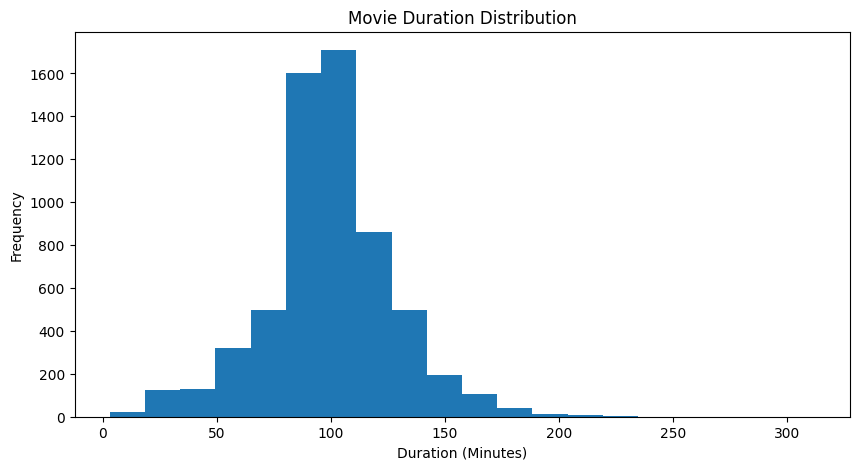

In [ ]:
movie_df = df[df["type"] == "Movie"]
movie_df["duration_value"] = movie_df["duration"].str.extract("(\d+)").astype(int)
plt.figure(figsize=(10,5))
plt.hist(movie_df["duration_value"],bins=20)
plt.title("Movie Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Frequency")
plt.show()

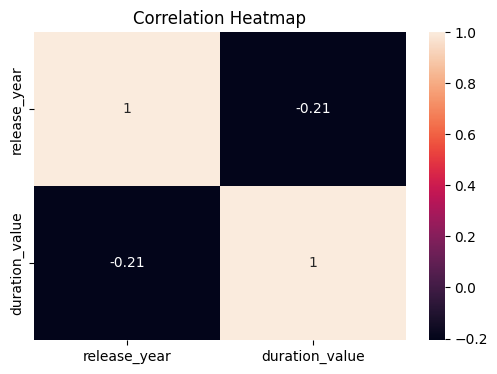

In [ ]:
numeric_df = movie_df[["release_year", "duration_value"]]

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

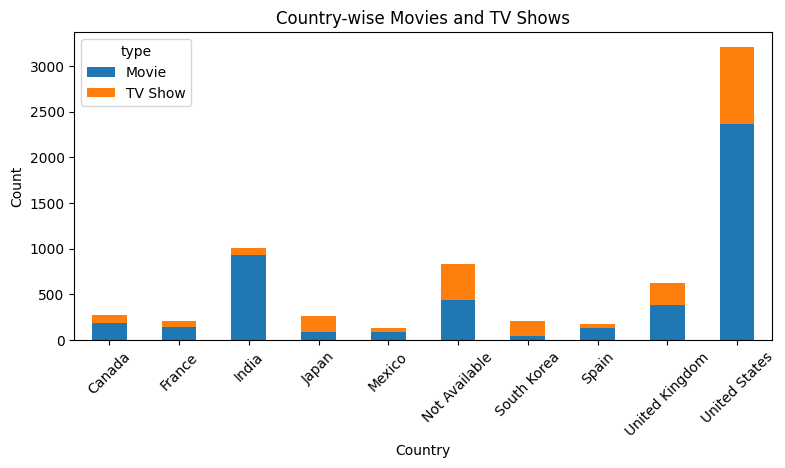

In [ ]:
country_type = df.copy()

country_type["country"] = country_type["country"].str.split(", ")
country_type = country_type.explode("country")
top_country = country_type["country"].value_counts().head(10).index
filtered = country_type[country_type["country"].isin(top_country)]
country_chart = pd.crosstab( filtered["country"], filtered["type"])
country_chart.plot( kind="bar", stacked=True,figsize=(9,4))
plt.title("Country-wise Movies and TV Shows")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# UNIVARIATE


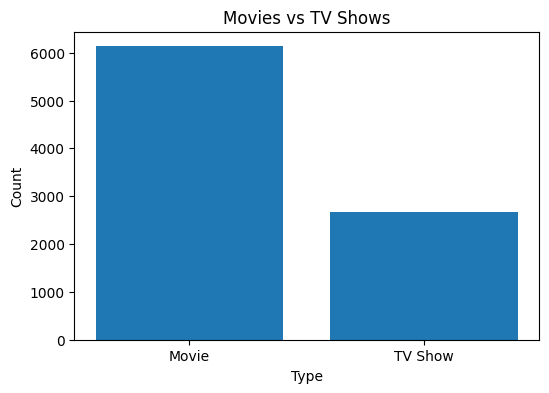

In [ ]:
import matplotlib.pyplot as plt

type_count = df['type'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(type_count.index, type_count.values)

plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

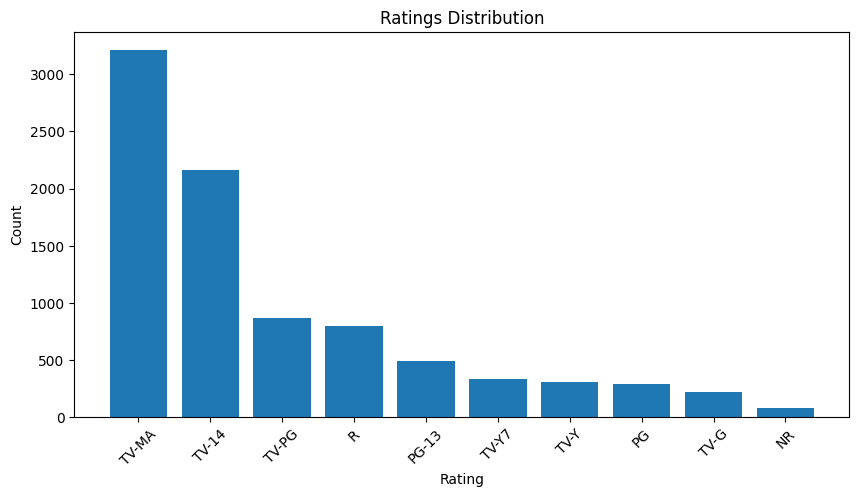

In [ ]:
rating_count = df['rating'].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(rating_count.index, rating_count.values)

plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

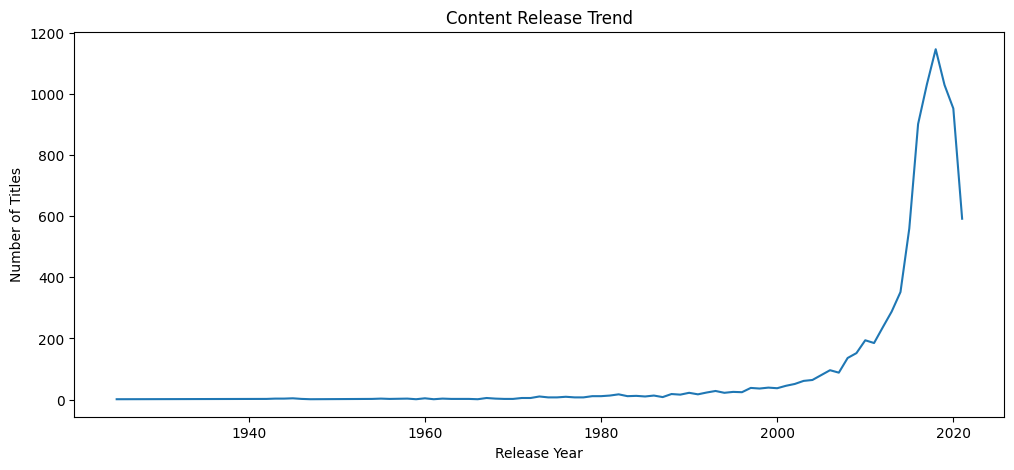

In [ ]:
release_year = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.plot(release_year.index, release_year.values)

plt.title("Content Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")


plt.show()

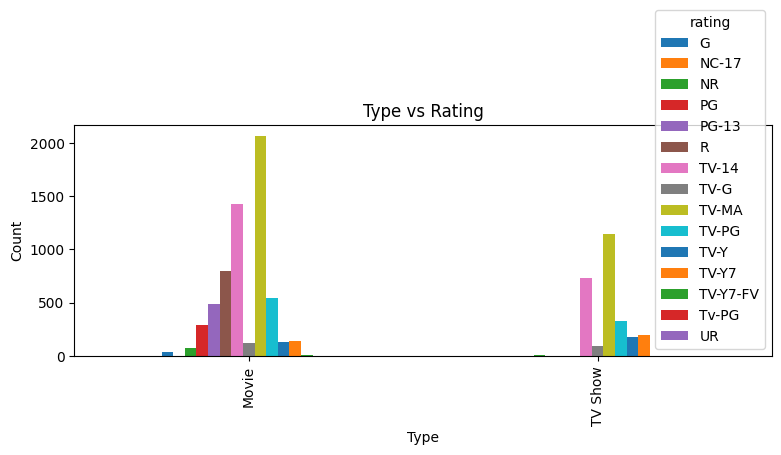

In [ ]:
type_rating = pd.crosstab(df['type'], df['rating'])
type_rating.plot(kind='bar', figsize=(9,3))
plt.title("Type vs Rating")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

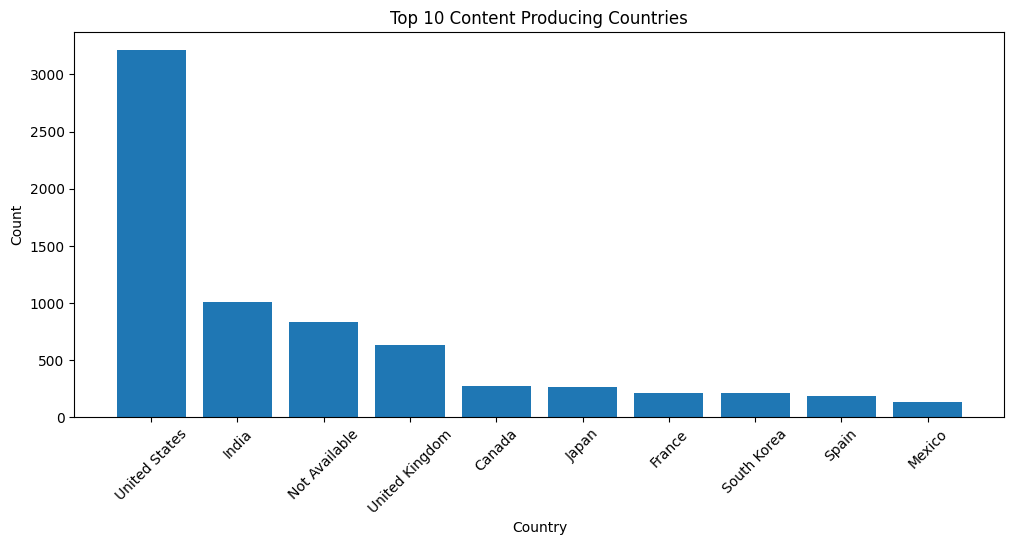

In [ ]:
country_count = df['country'].value_counts().head(10)

plt.figure(figsize=(12,5))
plt.bar(country_count.index, country_count.values)

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

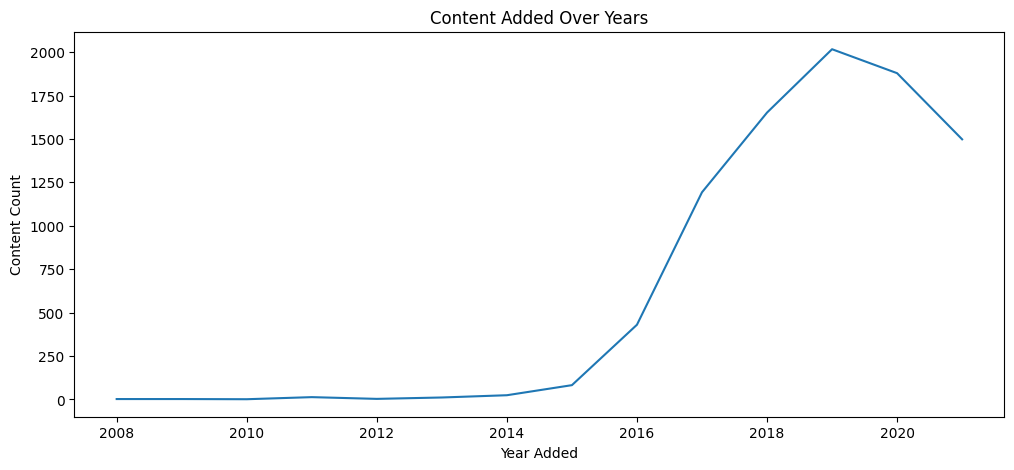

In [ ]:
df['year_added'] = df['date_added'].dt.year

year_added = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.plot(year_added.index, year_added.values)

plt.title("Content Added Over Years")
plt.xlabel("Year Added")
plt.ylabel("Content Count")

plt.show()

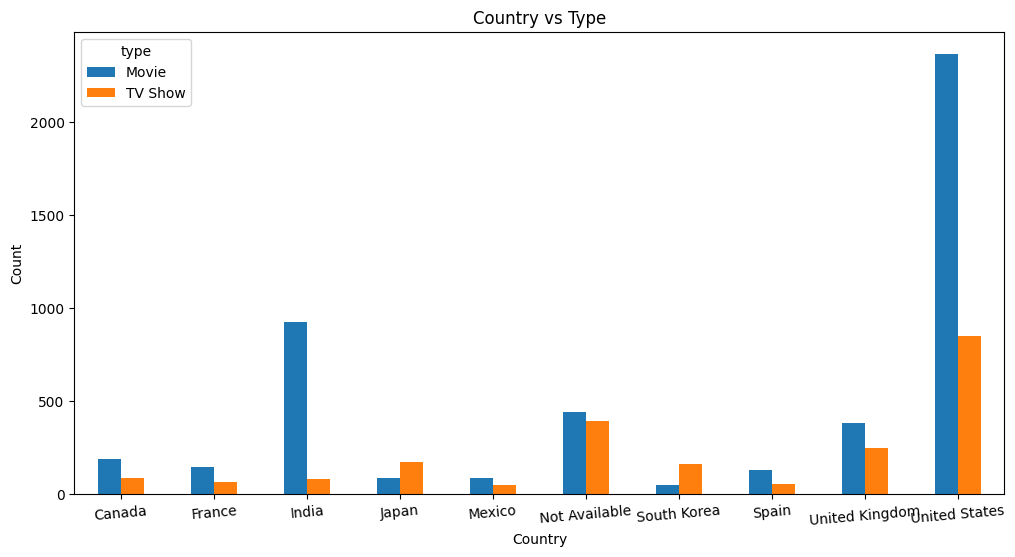

In [ ]:
top_country = df[df['country'].isin(df['country'].value_counts().head(10).index)]

country_type = pd.crosstab(top_country['country'], top_country['type'])

country_type.plot(kind='bar', figsize=(12,6))

plt.title("Country vs Type")
plt.xlabel("Country")
plt.ylabel("Count")

plt.xticks(rotation=5)

plt.show()

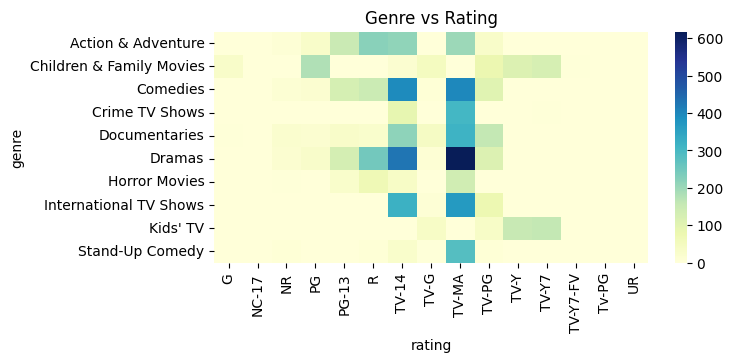

In [ ]:
import seaborn as sns
top_genre = df[df['genre'].isin(df['genre'].value_counts().head(10).index)]
heatmap_data = pd.crosstab(top_genre['genre'], top_genre['rating'])
plt.figure(figsize=(7,3))
sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title("Genre vs Rating")
plt.show()

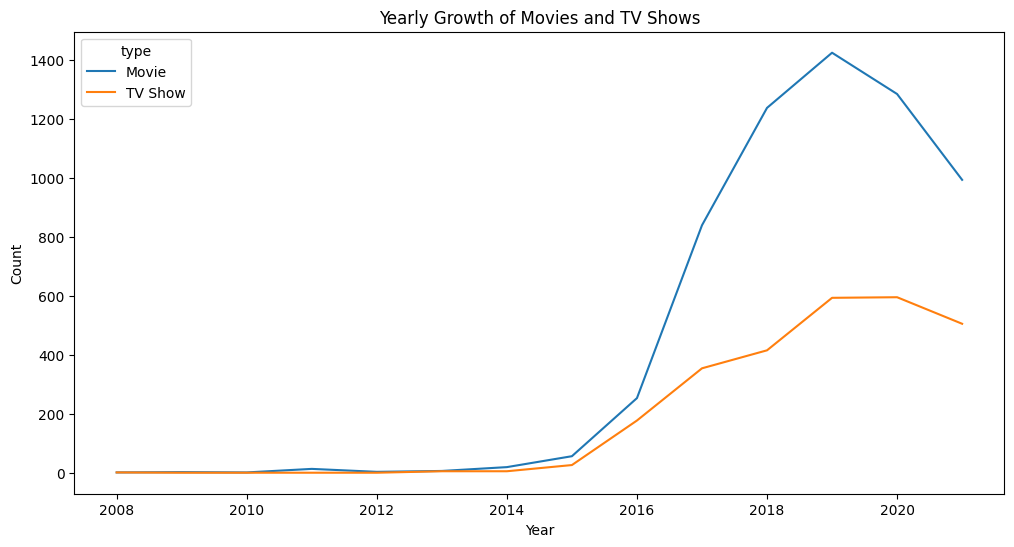

In [ ]:
multi = pd.crosstab(df['year_added'], df['type'])

multi.plot(figsize=(12,6))

plt.title("Yearly Growth of Movies and TV Shows")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()